In [1]:
import pandas as pd
path   = "/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/src/keras/predictions_fnn_with_target.csv"
df_final = pd.read_csv(path)
df_final.head()

,CODIGO_FAMILIA,COD_SUBCATEGORIA,NOMBRE_SUBCATEGORIA,recencia_hl,freq_baja,freq_media,freq_alta,cv_invertido,Ciclos_cv,sow_24m,season_ratio,ciclo_min,ciclo_promedio,ciclo_max,Ciclos_ciclo_dias,Ciclos_gaps_normalizados,Ciclos_tipo_ciclo,fnn_prob,target
0,1800577643,7044,ANTIHISTAMINICO,0.618297,1,1,0,0.520503,0.479497,0.222826,0.990000,25.162500,33.000000,72.187500,"[25.162499999999998, 33.0, 72.1875]","[6.0, 1.0, 5.0, 7.0]",corto_medio,0.262109,0
1,1800477992,6853,ANTICONVULSIVANTE ADULTO SIST NERVIOSO,0.015006,1,1,0,0.242723,0.757277,0.512315,0.990000,43.615000,57.200000,125.125000,"[43.615, 57.2, 125.125]","[1.0, 2.5, 4.0, 3.0, 10.0]",corto_medio,0.268016,0
2,1800477992,9324,ANTIGLAUCOMATOSOS,0.160167,1,0,0,0.507425,0.492575,0.433498,0.950000,27.640625,36.250000,79.296875,"[27.640625, 36.25, 79.296875]","[3.0, 2.0, 4.5, 1.0, 1.0, 3.0, 4.5, 2.0]",corto_medio,0.328709,0
3,1800477992,2422,VITAMINOTERAPIA C,0.976645,1,1,0,0.336675,0.663325,0.413793,0.950000,35.837500,47.000000,102.812500,"[35.8375, 47.0, 102.8125]","[1.3333333333333333, 3.3333333333333335, 1.0, ...",corto_medio,0.277239,0
4,1800477992,9264,ANTIMIGRAÑOSO MENOR,0.002228,0,0,0,0.417591,0.582409,0.733990,0.636804,44.097917,57.833333,126.510417,"[44.09791666666666, 57.833333333333336, 126.51...","[1.0, 2.0, 8.5, 5.0, 5.0, 3.5]",corto_medio,0.300874,1


In [2]:
df_final['rank_prob'] = df_final.groupby(['CODIGO_FAMILIA'])["fnn_prob"].rank(method="first", ascending=False)
df_final['recomendacion'] = (df_final['rank_prob'] <= 3).astype(int)


In [6]:
columnas_usar = ['fnn_prob','target','Ciclos_tipo_ciclo','recomendacion']
df_analisis = df_final[columnas_usar].copy()
df_analisis['score_round'] = df_analisis['fnn_prob'].round(1)

df_analisis_group_total = df_analisis.groupby(['score_round','Ciclos_tipo_ciclo']).agg(
    Total_general=('target', 'count'),
    target_1=('target', lambda x: (x==1).sum()),
    target_0=('target', lambda x: (x==0).sum()),
    recomendacion_1=('recomendacion', lambda x: (x==1).sum()),
    recomendacion_0=('recomendacion', lambda x: (x==0).sum()),
    target1_reco1=('target', lambda x: ((x==1) & (df_analisis.loc[x.index, 'recomendacion'].eq(1))).sum()),
    target0_reco1 = ('target', lambda x: ((x==0) & (df_analisis.loc[x.index, 'recomendacion'].eq(1))).sum())
    

).reset_index()



In [7]:
df_analisis_group_total

,score_round,Ciclos_tipo_ciclo,Total_general,target_1,target_0,recomendacion_1,recomendacion_0,target1_reco1,target0_reco1
0,0.1,corto_medio,96,19,77,29,67,5,24
1,0.2,corto_medio,2665,567,2098,863,1802,170,693
2,0.3,corto_medio,5259,1695,3564,3423,1836,1110,2313
3,0.4,corto_medio,1477,563,914,1457,20,555,902
4,0.5,corto_medio,54,27,27,54,0,27,27


In [9]:
df_analisis_group_total['P_compra_21_1' ] = round(df_analisis_group_total['target_1']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['P_compra_21_0' ] = round(df_analisis_group_total['target_0']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['Acertividad'] = round(df_analisis_group_total['target1_reco1'] / df_analisis_group_total['target_1']*100,2)
df_analisis_group_total[['score_round','Ciclos_tipo_ciclo','Total_general','target_1','target_0','target1_reco1','target0_reco1','Acertividad'] ]

,score_round,Ciclos_tipo_ciclo,Total_general,target_1,target_0,target1_reco1,target0_reco1,Acertividad
0,0.1,corto_medio,96,19,77,5,24,26.32
1,0.2,corto_medio,2665,567,2098,170,693,29.98
2,0.3,corto_medio,5259,1695,3564,1110,2313,65.49
3,0.4,corto_medio,1477,563,914,555,902,98.58
4,0.5,corto_medio,54,27,27,27,27,100.00


In [ ]:
(5554/207888) *100

2.671630878165166

## Matriz de confusión de las caracteriscas contra fnn_prob

ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES

📂 Cargando predictions_fnn_with_target.csv...
   ✓ 9551 registros

📊 Calculando correlaciones...
   Features analizadas: 7
   Registros: 9551

📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB

Feature               Correlación Barra                         
-----------------------------------------------------------------
sow_24m              +    0.4348  █████████████
cv_invertido         -    0.0222  
recencia_hl          -    0.2602  ███████
season_ratio         -    0.2616  ███████
freq_baja            -    0.3635  ██████████
freq_alta            -    0.5992  █████████████████
freq_media           -    0.6780  ████████████████████

💾 Guardado: correlaciones_fnn.csv

📊 MATRIZ DE CORRELACIÓN COMPLETA
              recencia_hl  freq_baja  freq_media  freq_alta  cv_invertido  \
recencia_hl        1.0000     0.2321      0.3330     0.1400        0.0303   
freq_baja          0.2321     1.0000      0.5412     0.1496        0.0352   
freq_media      

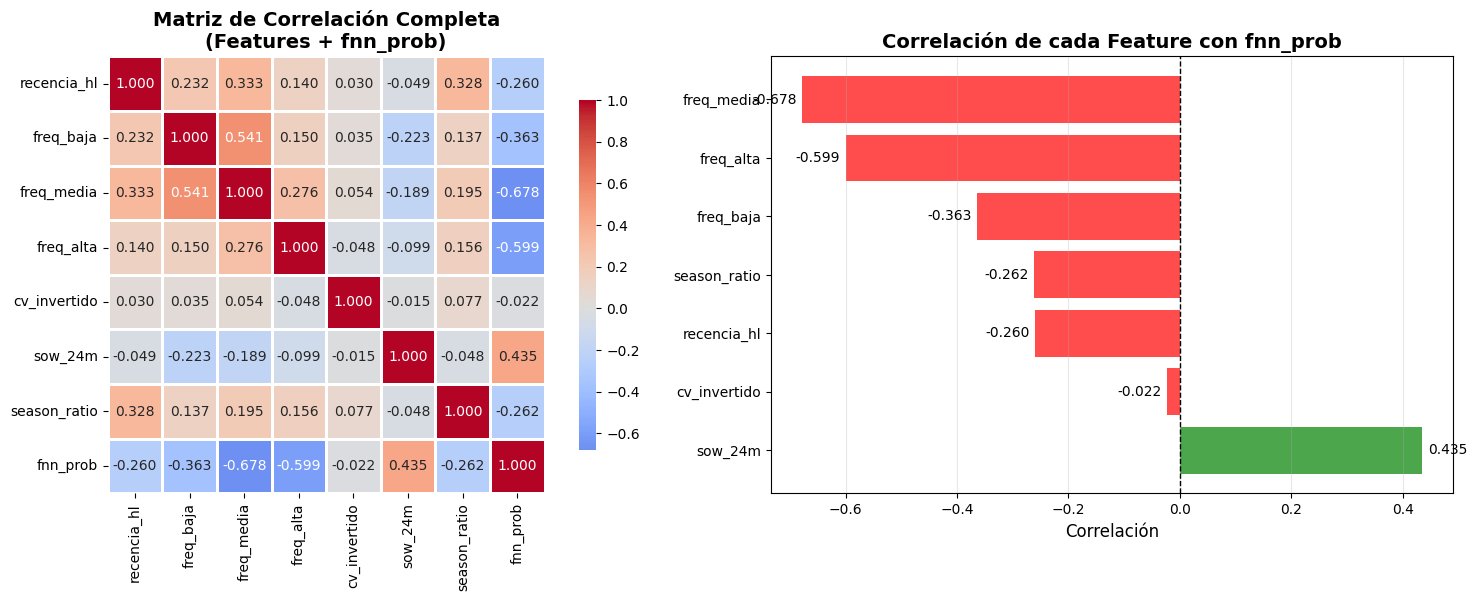

In [5]:
"""
Análisis de correlación: fnn_prob vs 7 features
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    print("=" * 80)
    print("ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES")
    print("=" * 80)
    
    # Cargar archivo
    print("\n📂 Cargando predictions_fnn_with_target.csv...")
    df = df_final.copy()
    print(f"   ✓ {len(df)} registros")
    
    # 7 features del modelo
    features = [
        'recencia_hl',
        'freq_baja',
        'freq_media',
        'freq_alta',
        'cv_invertido',
        'sow_24m',
        'season_ratio'
    ]
    
    # Agregar fnn_prob para correlación
    cols_correlacion = features + ['fnn_prob']
    
    # Filtrar solo columnas numéricas
    df_corr = df[cols_correlacion].copy()
    
    print(f"\n📊 Calculando correlaciones...")
    print(f"   Features analizadas: {len(features)}")
    print(f"   Registros: {len(df_corr)}")
    
    # Matriz de correlación completa
    corr_matrix = df_corr.corr()
    
    # Extraer solo correlaciones con fnn_prob
    corr_with_prob = corr_matrix['fnn_prob'].drop('fnn_prob').sort_values(ascending=False)
    
    print("\n" + "=" * 80)
    print("📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB")
    print("=" * 80)
    
    print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
    print("-" * 65)
    
    for feature, corr in corr_with_prob.items():
        # Barra visual
        bar_length = int(abs(corr) * 30)
        bar = "█" * bar_length
        sign = "+" if corr >= 0 else "-"
        
        print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
    
    # Guardar correlaciones en CSV
    corr_df = pd.DataFrame({
        'feature': corr_with_prob.index,
        'correlacion': corr_with_prob.values
    })
    corr_df.to_csv('correlaciones_fnn.csv', index=False)
    print(f"\n💾 Guardado: correlaciones_fnn.csv")
    
    # Matriz completa
    print("\n" + "=" * 80)
    print("📊 MATRIZ DE CORRELACIÓN COMPLETA")
    print("=" * 80)
    print(corr_matrix.round(4))
    
    corr_matrix.to_csv('matriz_correlacion_completa.csv')
    print(f"\n💾 Guardado: matriz_correlacion_completa.csv")
    
    # Visualización
    print("\n🎨 Generando visualización...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Heatmap de matriz completa
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[0])
    axes[0].set_title('Matriz de Correlación Completa\n(Features + fnn_prob)', 
                      fontsize=14, fontweight='bold')
    
    # 2. Barras de correlación con fnn_prob
    colors = ['green' if x > 0 else 'red' for x in corr_with_prob.values]
    axes[1].barh(range(len(corr_with_prob)), corr_with_prob.values, color=colors, alpha=0.7)
    axes[1].set_yticks(range(len(corr_with_prob)))
    axes[1].set_yticklabels(corr_with_prob.index)
    axes[1].set_xlabel('Correlación', fontsize=12)
    axes[1].set_title('Correlación de cada Feature con fnn_prob', 
                      fontsize=14, fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Agregar valores en las barras
    for i, v in enumerate(corr_with_prob.values):
        axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('correlacion_features_fnn.png', dpi=150, bbox_inches='tight')
    print(f"   ✓ Guardado: correlacion_features_fnn.png")
    
    # Análisis adicional: correlación con target
    if 'target' in df.columns:
        print("\n" + "=" * 80)
        print("🎯 CORRELACIÓN CON TARGET (compras reales)")
        print("=" * 80)
        
        cols_target = features + ['fnn_prob', 'target']
        corr_target = df[cols_target].corr()['target'].drop('target').sort_values(ascending=False)
        
        print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
        print("-" * 65)
        
        for feature, corr in corr_target.items():
            bar_length = int(abs(corr) * 30)
            bar = "█" * bar_length
            sign = "+" if corr >= 0 else "-"
            print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
        
        # Comparación lado a lado
        comparison = pd.DataFrame({
            'feature': corr_with_prob.index,
            'corr_con_fnn_prob': corr_with_prob.values,
            'corr_con_target': [corr_target[f] for f in corr_with_prob.index]
        })
        comparison.to_csv('comparacion_correlaciones.csv', index=False)
        print(f"\n💾 Guardado: comparacion_correlaciones.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANÁLISIS COMPLETADO")
    print("=" * 80)
    
    print("\n📁 Archivos generados:")
    print("   1. correlaciones_fnn.csv - Correlación features vs fnn_prob")
    print("   2. matriz_correlacion_completa.csv - Matriz completa")
    print("   3. correlacion_features_fnn.png - Visualización")
    if 'target' in df.columns:
        print("   4. comparacion_correlaciones.csv - Comparación fnn_prob vs target")
    
    print("\n💡 Interpretación:")
    print("   - Valores cercanos a +1: correlación positiva fuerte")
    print("   - Valores cercanos a -1: correlación negativa fuerte")
    print("   - Valores cercanos a 0: sin correlación")
    print("=" * 80)


if __name__ == "__main__":
    main()


### Análisis con familias con mayores ventas solo 665 primeras familias

In [ ]:
import pandas as pd
path   = "/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/src/keras/predictions_fnn_with_target.csv"
df_final = pd.read_csv(path)
df_final['rank_prob'] = df_final.groupby(['CODIGO_FAMILIA'])["fnn_prob"].rank(method="first", ascending=False)
df_final['recomendacion'] = (df_final['rank_prob'] <= 3).astype(int)
columnas_usar = ['fnn_prob','target','Ciclos_tipo_ciclo','recomendacion']
df_analisis = df_final[columnas_usar].copy()
df_analisis['score_round'] = df_analisis['fnn_prob'].round(1)

df_analisis_group_total = df_analisis.groupby(['score_round']).agg(
    Total_general=('target', 'count'),
    target_1=('target', lambda x: (x==1).sum()),
    target_0=('target', lambda x: (x==0).sum()),
    recomendacion_1=('recomendacion', lambda x: (x==1).sum()),
    recomendacion_0=('recomendacion', lambda x: (x==0).sum()),
    target1_reco1=('target', lambda x: ((x==1) & (df_analisis.loc[x.index, 'recomendacion'].eq(1))).sum())

).reset_index()
df_analisis_group_total['P_compra_21_1' ] = round(df_analisis_group_total['target_1']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['P_compra_21_0' ] = round(df_analisis_group_total['target_0']/df_analisis_group_total['Total_general'] * 100,2)
df_analisis_group_total['Acertividad'] = round(df_analisis_group_total['target1_reco1'] / df_analisis_group_total['target_1']*100,2)
df_analisis_group_total[['score_round','Total_general','target_1','target_0','target1_reco1','Acertividad'] ]

,score_round,Total_general,target_1,target_0,target1_reco1,Acertividad
0,0.0,205020,2048,202972,0,0.00
1,0.1,55469,1950,53519,0,0.00
2,0.2,12426,1221,11205,40,3.28
3,0.3,4392,731,3661,120,16.42
4,0.4,3210,632,2578,431,68.20
5,0.5,1383,327,1056,304,92.97
6,0.6,391,102,289,102,100.00


ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES

📂 Cargando predictions_fnn_with_target.csv...
   ✓ 282291 registros

📊 Calculando correlaciones...
   Features analizadas: 7
   Registros: 282291

📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB

Feature               Correlación Barra                         
-----------------------------------------------------------------
sow_24m              +    0.8491  █████████████████████████
season_ratio         +    0.7643  ██████████████████████
recencia_hl          +    0.6457  ███████████████████
freq_baja            +    0.6086  ██████████████████
cv_invertido         +    0.5537  ████████████████
freq_media           +    0.4735  ██████████████
freq_alta            +    0.1525  ████

💾 Guardado: correlaciones_fnn.csv

📊 MATRIZ DE CORRELACIÓN COMPLETA
              recencia_hl  freq_baja  freq_media  freq_alta  cv_invertido  \
recencia_hl        1.0000     0.7519      0.7083     0.3939        0.4764   
freq_baja          0.7519     1.0000      0.8

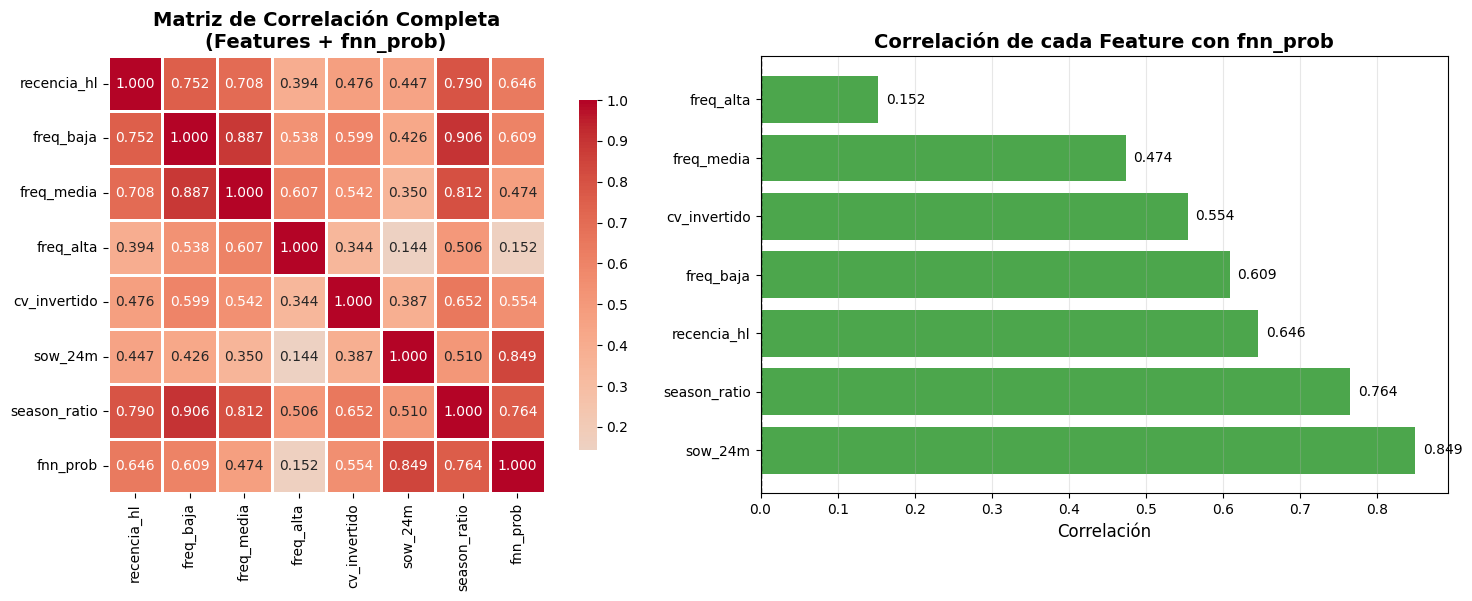

In [6]:
"""
Análisis de correlación: fnn_prob vs 7 features
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def main():
    print("=" * 80)
    print("ANÁLISIS DE CORRELACIÓN: FNN_PROB vs FEATURES")
    print("=" * 80)
    
    # Cargar archivo
    print("\n📂 Cargando predictions_fnn_with_target.csv...")
    df = df_final.copy()
    print(f"   ✓ {len(df)} registros")
    
    # 7 features del modelo
    features = [
        'recencia_hl',
        'freq_baja',
        'freq_media',
        'freq_alta',
        'cv_invertido',
        'sow_24m',
        'season_ratio'
    ]
    
    # Agregar fnn_prob para correlación
    cols_correlacion = features + ['fnn_prob']
    
    # Filtrar solo columnas numéricas
    df_corr = df[cols_correlacion].copy()
    
    print(f"\n📊 Calculando correlaciones...")
    print(f"   Features analizadas: {len(features)}")
    print(f"   Registros: {len(df_corr)}")
    
    # Matriz de correlación completa
    corr_matrix = df_corr.corr()
    
    # Extraer solo correlaciones con fnn_prob
    corr_with_prob = corr_matrix['fnn_prob'].drop('fnn_prob').sort_values(ascending=False)
    
    print("\n" + "=" * 80)
    print("📈 CORRELACIÓN DE CADA FEATURE CON FNN_PROB")
    print("=" * 80)
    
    print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
    print("-" * 65)
    
    for feature, corr in corr_with_prob.items():
        # Barra visual
        bar_length = int(abs(corr) * 30)
        bar = "█" * bar_length
        sign = "+" if corr >= 0 else "-"
        
        print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
    
    # Guardar correlaciones en CSV
    corr_df = pd.DataFrame({
        'feature': corr_with_prob.index,
        'correlacion': corr_with_prob.values
    })
    corr_df.to_csv('correlaciones_fnn.csv', index=False)
    print(f"\n💾 Guardado: correlaciones_fnn.csv")
    
    # Matriz completa
    print("\n" + "=" * 80)
    print("📊 MATRIZ DE CORRELACIÓN COMPLETA")
    print("=" * 80)
    print(corr_matrix.round(4))
    
    corr_matrix.to_csv('matriz_correlacion_completa.csv')
    print(f"\n💾 Guardado: matriz_correlacion_completa.csv")
    
    # Visualización
    print("\n🎨 Generando visualización...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Heatmap de matriz completa
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                ax=axes[0])
    axes[0].set_title('Matriz de Correlación Completa\n(Features + fnn_prob)', 
                      fontsize=14, fontweight='bold')
    
    # 2. Barras de correlación con fnn_prob
    colors = ['green' if x > 0 else 'red' for x in corr_with_prob.values]
    axes[1].barh(range(len(corr_with_prob)), corr_with_prob.values, color=colors, alpha=0.7)
    axes[1].set_yticks(range(len(corr_with_prob)))
    axes[1].set_yticklabels(corr_with_prob.index)
    axes[1].set_xlabel('Correlación', fontsize=12)
    axes[1].set_title('Correlación de cada Feature con fnn_prob', 
                      fontsize=14, fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Agregar valores en las barras
    for i, v in enumerate(corr_with_prob.values):
        axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('correlacion_features_fnn.png', dpi=150, bbox_inches='tight')
    print(f"   ✓ Guardado: correlacion_features_fnn.png")
    
    # Análisis adicional: correlación con target
    if 'target' in df.columns:
        print("\n" + "=" * 80)
        print("🎯 CORRELACIÓN CON TARGET (compras reales)")
        print("=" * 80)
        
        cols_target = features + ['fnn_prob', 'target']
        corr_target = df[cols_target].corr()['target'].drop('target').sort_values(ascending=False)
        
        print(f"\n{'Feature':<20} {'Correlación':>12} {'Barra':<30}")
        print("-" * 65)
        
        for feature, corr in corr_target.items():
            bar_length = int(abs(corr) * 30)
            bar = "█" * bar_length
            sign = "+" if corr >= 0 else "-"
            print(f"{feature:<20} {sign}{abs(corr):>10.4f}  {bar}")
        
        # Comparación lado a lado
        comparison = pd.DataFrame({
            'feature': corr_with_prob.index,
            'corr_con_fnn_prob': corr_with_prob.values,
            'corr_con_target': [corr_target[f] for f in corr_with_prob.index]
        })
        comparison.to_csv('comparacion_correlaciones.csv', index=False)
        print(f"\n💾 Guardado: comparacion_correlaciones.csv")
    
    print("\n" + "=" * 80)
    print("✅ ANÁLISIS COMPLETADO")
    print("=" * 80)
    
    print("\n📁 Archivos generados:")
    print("   1. correlaciones_fnn.csv - Correlación features vs fnn_prob")
    print("   2. matriz_correlacion_completa.csv - Matriz completa")
    print("   3. correlacion_features_fnn.png - Visualización")
    if 'target' in df.columns:
        print("   4. comparacion_correlaciones.csv - Comparación fnn_prob vs target")
    
    print("\n💡 Interpretación:")
    print("   - Valores cercanos a +1: correlación positiva fuerte")
    print("   - Valores cercanos a -1: correlación negativa fuerte")
    print("   - Valores cercanos a 0: sin correlación")
    print("=" * 80)


if __name__ == "__main__":
    main()


# Generación Hoja de Analisís

In [134]:
import pandas as pd
path   = "/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/predictions_fnn_final.csv"
df_final = pd.read_csv(path)

In [135]:
df_final.columns

Index(['COD_SUBCATEGORIA', 'recencia_hl', 'freq_baja', 'freq_media',
       'freq_alta', 'cv_invertido', 'sow_24m', 'season_ratio', 'score_final',
       'Ciclos_CODIGO_FAMILIA', 'Ciclos_ciclo_dias', 'Ciclos_cv',
       'Ciclos_tipo_ciclo', 'Ciclos_gaps_originales_dias',
       'Ciclos_gaps_normalizados', 'Ciclos_gaps_ciclos_bloques',
       'Recencia_castigo_recencia', 'Recencia_l_compra_sobre_ciclo',
       'Recencia_dias_desde_ultima_compra', 'Recencia_recencia',
       'Freq_compras_reales', 'Freq_periodo_revision',
       'Sow_transacciones_netas', 'Seasonality_compras_actual',
       'Seasonality_compras_pasado', 'Seasonality_ratio_temporal',
       'CODIGO_FAMILIA', 'fnn_prob'],
      dtype='object')

In [4]:
df_final = file_read.read_historico(tipo='predictions_fnn',path=None)


In [ ]:
df_test = file_read.read_historico(tipo='test')
df_test = df_test[df_test['DIM_PERIODO'] <= pd.Timestamp('2025-12-21')]

df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   IDENTIFICACION             42786 non-null  int64         
 1   COD_SUBCATEGORIA           42786 non-null  int64         
 2   NOMBRE_SUBCATEGORIA        42786 non-null  object        
 3   NOMBRE_UNIDAD_COMERCIAL    42786 non-null  object        
 4   COD_CATEGORIA              42786 non-null  int64         
 5   NOMBRE_CATEGORIA           42786 non-null  object        
 6   COD_UNIDAD_COMERCIAL       42786 non-null  int64         
 7   COD_ITEM                   42786 non-null  int64         
 8   NOMBRE_ITEM                42786 non-null  object        
 9   DIM_PERIODO                42786 non-null  datetime64[ns]
 10  CANTIDAD_SUELTA            42786 non-null  int64         
 11  CANTIDAD_CAJA              42786 non-null  float64       
 12  PVP 

In [29]:
import sys
import pandas as pd
import json
sys.path.append('/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN')
import file_read 

df_final = file_read.read_historico(tipo='predictions_fnn',path=None)


############################## GENERACION DE NUEVAS COLUMNAS CICLOS Y FRECUENCA PARA DEBUG ##########################################
df_final['Ciclos_ciclo_dias_to_list'] = df_final['Ciclos_ciclo_dias'].apply(lambda x: x[1:-1].split(','))
df_final['ciclo_baja'] = df_final['Ciclos_ciclo_dias_to_list'].apply(lambda x: x[0])
df_final['ciclo_media'] = df_final['Ciclos_ciclo_dias_to_list'].apply(lambda x: x[1])
df_final['ciclo_alta'] = df_final['Ciclos_ciclo_dias_to_list'].apply(lambda x: x[2])
df_final['ciclo_baja'] = df_final['ciclo_baja'].astype(float).astype(int)
df_final['ciclo_media'] = df_final['ciclo_media'].astype(float).astype(int)
df_final['ciclo_alta'] = df_final['ciclo_alta'].astype(float).astype(int)
df_final['Freq_periodo_revision'] = df_final['Freq_periodo_revision'].astype(int)
mask_perido_revision = df_final['Freq_periodo_revision'] != 0
df_final['freq_compras_esperadas_baja'] = 0
df_final['freq_compras_esperadas_media'] = 0
df_final['freq_compras_esperadas_alta'] = 0

df_final.loc[mask_perido_revision, 'freq_compras_esperadas_baja'] = round(df_final.loc[mask_perido_revision, 'Freq_periodo_revision'] / df_final.loc[mask_perido_revision, 'ciclo_baja'], 1)
df_final.loc[mask_perido_revision, 'freq_compras_esperadas_media'] = round(df_final.loc[mask_perido_revision, 'Freq_periodo_revision'] / df_final.loc[mask_perido_revision, 'ciclo_media'], 1)
df_final.loc[mask_perido_revision, 'freq_compras_esperadas_alta'] = round(df_final.loc[mask_perido_revision, 'Freq_periodo_revision'] / df_final.loc[mask_perido_revision, 'ciclo_alta'], 1)

#######################################################################################
#HISTOTICO
df_historico = file_read.read_historico(tipo='historico')
df_historico = df_historico[df_historico['DIM_PERIODO'] < '2025-12-01']

df_historico = df_historico.groupby(['CODIGO_FAMILIA','COD_SUBCATEGORIA']).agg(
    Fecha_ultima_compra= ('DIM_PERIODO', 'max'),
    NOMBRE_SUBCATEGORIA_a= ('NOMBRE_SUBCATEGORIA','first'),
    DIVISION_COMERCIAL_A = ('NOMBRE_DIVISION_COMERCIAL','first'),
    ).reset_index()

#######################################################################################
#DATA TEST
df_test = file_read.read_historico(tipo='test')
df_test = df_test[df_test['DIM_PERIODO'] <= '2025-12-21']
df_test = df_test.groupby(['CODIGO_FAMILIA','COD_SUBCATEGORIA']).agg(
    Compras_validacion= ('DIM_PERIODO','nunique')
    
).reset_index()


#######################################################################################
columnas_finales  = ['CODIGO_FAMILIA','COD_SUBCATEGORIA','NOMBRE_SUBCATEGORIA',
 'fnn_prob','top_score','target',
 'Ciclos_tipo_ciclo','ciclo_baja', 'ciclo_media', 'ciclo_alta','Ciclos_gaps_originales_dias','Ciclos_cv',
 'Ciclos_gaps_ciclos_bloques','Ciclos_gaps_normalizados',
 'recencia_hl','Recencia_dias_desde_ultima_compra',
 'CV_politica','Politica_min_max',
 'Fecha_ultima_compra',
 'Compras_validacion',
 'Freq_periodo_revision','Freq_compras_reales','frec_baja', 'frec_media', 'frec_alta',
 'freq_compras_esperadas_baja', 'freq_compras_esperadas_media','freq_compras_esperadas_alta',
 'Sow_transacciones_netas','sow_24m',
 'Seasonality_compras_actual','Seasonality_compras_pasado','season_ratio'
 ]


cv_threshold = {
    'corto': 1,
    'corto_medio': 0.95,
    'mediano': 0.6,
    'largo': 0.45,
    'no_ciclico': 0
}
# DICCIONARIO 2: Rango de días (segundo elemento)
rango_dias = {
    'corto': '3:30',
    'corto_medio': '30:75',
    'mediano': '75:150',
    'largo': '150:360',
    'no_ciclico': None
}

rango_bajos_altos = {

    'corto': '0.25:2',
    'corto_medio': '0.25:1.25',
    'mediano': '0.25:0.75',
    'largo': '0.25:0.3',
    'no_ciclico': None
}

compras_minimas = {
    'corto': 5,
    'corto_medio': 5,
    'mediano': 4,
    'largo': 4,
    'no_ciclico': 0
}

maping_nombres = {
    'CODIGO_FAMILIA': 'Cod Familia',
    'COD_SUBCATEGORIA': 'Cod Subcategoria',
    'NOMBRE_SUBCATEGORIA_a': 'Nombre Subcategoria', # FALTA HISTORICO ok
    'DIVISION_COMERCIAL_A': 'Nombre Division Comercial',
    'fnn_prob': 'Score',
    'top_score':'Top Score', # FALTA CALCULADA
    'target':'Venta', #FALTA TEST_DATA 21 DIAS OK 
    'Ciclos_tipo_ciclo':'Tipo Ciclo',
    'Debug_ciclos_tipo_ciclo_b': 'Tipo Ciclo B',
    'Ciclos_ciclo_binario_c': 'Politica Ciclo',
    'Ciclos_razon':'Razon Ciclo',
    'ciclo_baja': 'Ciclo Min',
    'ciclo_media': 'Ciclo',
    'ciclo_alta': 'Ciclo Max',
    'Ciclos_gaps_originales_dias':'Ciclos',
    'Ciclos_gaps_ciclos_bloques':'Ciclos Bloques',
    'Ciclos_gaps_normalizados':'Ciclos Normalizados',
    'Ciclos_cv':'CV Ciclo',
    'ciclo_dias_mu':'Ciclo Dias Mu',
    'CV_politica':'CV Politica', # FALTA  MAP POLITICA 0 OK
    'Politica_dias': 'Politica Dias', # FALTA MAP POLITICA 1 OK
    'Politica_min_max': 'Politica Min Max', # FALTA MAP POLITICA 1 OK
    'Politica_Compras_minimas': 'Politica Compras Min', # FALTA MAP POLITICA 1 OK
    'Fecha_ultima_compra':'Fecha Ultima Compra', # FALTA HISTORICO ok
    'Recencia_dias_desde_ultima_compra':'Dias Recencia',
    'Calc_Recencia':'Calc Recencia', #NUEVA
    'Dif_calc_recencia':'Dif Calc Recencia', # NUEVA
    'recencia_hl':'Recencia',
    'Freq_periodo_revision':'Periodo Revision',
    'Freq_compras_reales':'Compras Reales',
    'Compras_validacion':'Compras Validacion', #  TEST_DATA 21 DIAS OK
    'Compras_totales':'Compras Totales', #NUEVA 
    'freq_compras_esperadas_baja':'Compra Tgt Max',
    'freq_compras_esperadas_media':'Compra Tgt Media',
    'freq_compras_esperadas_alta':'Compra Tgt Min',
    '%_Cump_Compra_Tgt_Max':'% Cump Compra Tgt Max', #NUEVA
    '%_Cump_Compra_Tgt_Media':'% Cump Compra Tgt Media', #NUEVA
    '%_Cump_Compra_Tgt_Min':'% Cump Compra Tgt Min', #NUEVA
    'freq_baja':'Frec Max',
    'freq_media':'Frec Media',
    'freq_alta':'Frec Min',
    'Sow_transacciones_netas':'Trx Historico',
    'Transacciones_max_familia':'Tx Max Familia',
    'sow_24m':'Sow',
    'Seasonality_compras_actual':'Compras Actuales',
    'Seasonality_compras_pasado':'Compras Pasadas',
    'Dif_compras':'Dif Compras', #NUEVA
    'season_ratio':'Estacionalidad'
    
}
#MERGE DIFERENTES DATAFRAMES Y CONSTRUCCUION DE DATAFRAME FINAL
df_final = pd.merge(df_final, df_historico, on=["CODIGO_FAMILIA", "COD_SUBCATEGORIA"], how="left")
df_final = df_final.merge(df_test, on=["CODIGO_FAMILIA", "COD_SUBCATEGORIA"], how="left")
df_final['target'] = (~df_final['Compras_validacion'].isnull()).astype(int) 

df_final['top_score'] = df_final.groupby('CODIGO_FAMILIA')['fnn_prob'].rank(ascending=False,method='first')
# Mapear CV
df_final['CV_politica'] = df_final['Ciclos_tipo_ciclo'].map(cv_threshold)
# Mapear rango
df_final['Politica_dias'] = df_final['Ciclos_tipo_ciclo'].map(rango_dias)
df_final['Politica_min_max'] = df_final['Ciclos_tipo_ciclo'].map(rango_bajos_altos)
df_final['Politica_Compras_minimas'] = df_final['Ciclos_tipo_ciclo'].map(compras_minimas)
df_final['Transacciones_max_familia'] = df_final.groupby('CODIGO_FAMILIA')['Sow_transacciones_netas'].transform('max')
df_final['Calc_Recencia'] = None
df_final['Dif_calc_recencia'] = None
df_final['Compras_totales'] = df_final['Freq_compras_reales'] + df_final['Compras_validacion']
df_final['%_Cump_Compra_Tgt_Max'] = None
df_final['%_Cump_Compra_Tgt_Media'] = None
df_final['%_Cump_Compra_Tgt_Min'] = None
df_final['Dif_compras'] = df_final['Seasonality_compras_pasado'] - df_final['Seasonality_compras_actual']


# 1. Obtener la lista de los NUEVOS nombres en el orden del diccionario
columnas_ordenadas = list(maping_nombres.keys())

# 2. Filtrar para asegurar que solo usas columnas que existen en tu dataframe
#    (Esto evita errores si alguna columna no se creó o renombró)
columnas_existentes_y_ordenadas = [col for col in columnas_ordenadas if col in df_final.columns]

# 3. Reordenar el DataFrame
df_ordenado = df_final[columnas_existentes_y_ordenadas]

#renombrar nombres columnas as maping_nombres
df_ordenado = df_ordenado.rename(columns=maping_nombres)




/tmp/ipykernel_78612/1730612760.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.9 5.4 4.3 ... 4.3 7.5 6. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_final.loc[mask_perido_revision, 'freq_compras_esperadas_baja'] = round(df_final.loc[mask_perido_revision, 'Freq_periodo_revision'] / df_final.loc[mask_perido_revision, 'ciclo_baja'], 1)
/tmp/ipykernel_78612/1730612760.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[3.3 4.6 3.1 ... 3.2 5.3 5.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_final.loc[mask_perido_revision, 'freq_compras_esperadas_media'] = round(df_final.loc[mask_perido_revision, 'Freq_periodo_revision'] / df_final.loc[mask_perido_revision, 'ciclo_media'], 1)
/tmp/ipykernel_78612/1730612760.py:26: Futur

In [2]:
import numpy as np
lista=[126, 111, 44, 12, 14, 5, 19, 9, 7, 16, 7, 6, 14, 5, 16, 4, 10, 5, 96, 18, 94, 96, 11, 10, 38, 22, 14, 15, 27]

media = np.mean(lista)
print("Media:", media)
mediana = np.median(lista)
print("Mediana:", mediana)
min_l = min(lista)
print("Mínimo:", min_l)
max_l = max(lista)
print("Máximo:", max_l)
desviacion_standar = np.std(lista)
print("Desviación estándar:", desviacion_standar)



Media: 30.03448275862069
Mediana: 14.0
Mínimo: 4
Máximo: 126
Desviación estándar: 35.56391309161062


In [5]:
lista = [
    18.00,
94.00,
96.00,
0.00,
10.00,
1.00,
10.00,
38.00,
22.00,
0.00,
14.00,
14.00,
1.00,
27.00
]

#media
mediana = np.median(lista)
print('mediana:',mediana)
media = np.mean(lista)
print('media:',media)

mediana: 14.0
media: 24.642857142857142


In [30]:
df_ordenado.to_excel('/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/outputs/train/df_final_cris.xlsx', index=False)

### Segundo Analisis

In [106]:
df_ordenado.columns

Index(['Cod Familia', 'Cod Subcategoria', 'Nombre Subcategoria',
       'Nombre Division Comercial', 'Score', 'Top Score', 'Venta',
       'Tipo Ciclo', 'Ciclo Min', 'Ciclo', 'Ciclo Max', 'Ciclos', 'CV Ciclo',
       'CV Politica', 'Politica Dias', 'Politica Min Max',
       'Politica Compras Min', 'Fecha Ultima Compra', 'Dias Recencia',
       'Calc Recencia', 'Dif Calc Recencia', 'Recencia', 'Periodo Revision',
       'Compras Reales', 'Compras Validacion', 'Compras Totales',
       'Compra Tgt Max', 'Compra Tgt Media', 'Compra Tgt Min',
       '% Cump Compra Tgt Max', '% Cump Compra Tgt Media',
       '% Cump Compra Tgt Min', 'Frec Max', 'Frec Media', 'Frec Min',
       'Trx Historico', 'Tx Max Familia', 'Sow', 'Compras Actuales',
       'Compras Pasadas', 'Dif Compras', 'Estacionalidad'],
      dtype='object')

In [109]:
### segundo analisis
df_ordenado['Recomendacion'] = (df_ordenado['Top Score'] < 4.0).astype(int)
df_ordenado['Recomendacion'].value_counts()

Recomendacion
0    273696
1      8673
Name: count, dtype: int64

In [111]:
columnas_usar = ['Score','Venta','Tipo Ciclo','Recomendacion']
df_analisis = df_ordenado[columnas_usar].copy()
df_analisis['score_round'] = df_analisis['Score'].round(1)

df_analisis_group_total = df_analisis.groupby(['score_round','Tipo Ciclo']).agg(
    Total_general=('Venta', 'count'),
    target_1=('Venta', lambda x: (x==1).sum()),
    target_0=('Venta', lambda x: (x==0).sum()),
    recomendacion_1=('Recomendacion', lambda x: (x==1).sum()),
    recomendacion_0=('Recomendacion', lambda x: (x==0).sum()),
    target1_reco1=('Venta', lambda x: ((x==1) & (df_analisis.loc[x.index, 'Recomendacion'].eq(1))).sum()),
    target0_reco1 = ('Venta', lambda x: ((x==0) & (df_analisis.loc[x.index, 'Recomendacion'].eq(1))).sum())
    

).reset_index()


In [26]:
#FILTRAR EN TEST 1719363028	8792
#df_test.columns
df_test = file_read.read_historico(tipo='test')
#df_test = df_test[df_test['DIM_PERIODO'] <= '2025-12-21']
df_test[(df_test['CODIGO_FAMILIA'] == 1719363028) & (df_test['COD_SUBCATEGORIA'] == 8792)]


,IDENTIFICACION,COD_SUBCATEGORIA,NOMBRE_SUBCATEGORIA,NOMBRE_UNIDAD_COMERCIAL,COD_CATEGORIA,NOMBRE_CATEGORIA,COD_UNIDAD_COMERCIAL,COD_ITEM,NOMBRE_ITEM,DIM_PERIODO,...,CODIGO_FAMILIA,COD_CANAL,NOMBRE_CANAL,COD_CLASIFICACION,NOMBRE_CLASIFICACION,COD_SUBCLASIFICACION,NOMBRE_SUBCLASIFICACION,NOMBRE_DIVISION_COMERCIAL,COD_DIVISION_COMERCIAL,TIPO
1228,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,550042,PAPAS RUFFLES NATURAL 68G,2025-12-30,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV
1229,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,550042,PAPAS RUFFLES NATURAL 68G,2025-12-30,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV
1232,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,144747,MANI MANICRIS SALADO 100 GR,2025-12-30,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV
38662,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,292037,PATACONES CHIFLAR JALAPEÑO 100 GR,2025-12-03,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV
38666,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,535633,CHICHARRON NATURAL 55GR,2025-12-03,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV
38782,1719363028,8792,COLACIONES Y SNACKS BIENESTAR,B&C,251,COLACIONES Y SNACKS,14,63136,GALLETA SIN AZUCAR GULLON DIET NAT.CHIP CHOCO ...,2025-12-03,...,1719363028,PR,PROPIO,PR_RTL,RETAIL,PR_RTL_RTL,RETAIL,CONSUMO,2,CNV


In [112]:
df_analisis_score = df_analisis_group_total.sort_values(by =['Tipo Ciclo','score_round'],ascending=[True,True])

In [133]:
df_ordenado.columns

Index(['Cod Familia', 'Cod Subcategoria', 'Nombre Subcategoria',
       'Nombre Division Comercial', 'Score', 'Top Score', 'Venta',
       'Tipo Ciclo', 'Ciclo Min', 'Ciclo', 'Ciclo Max', 'Ciclos', 'CV Ciclo',
       'CV Politica', 'Politica Dias', 'Politica Min Max',
       'Politica Compras Min', 'Fecha Ultima Compra', 'Dias Recencia',
       'Calc Recencia', 'Dif Calc Recencia', 'Recencia', 'Periodo Revision',
       'Compras Reales', 'Compras Validacion', 'Compras Totales',
       'Compra Tgt Max', 'Compra Tgt Media', 'Compra Tgt Min',
       '% Cump Compra Tgt Max', '% Cump Compra Tgt Media',
       '% Cump Compra Tgt Min', 'Frec Max', 'Frec Media', 'Frec Min',
       'Trx Historico', 'Tx Max Familia', 'Sow', 'Compras Actuales',
       'Compras Pasadas', 'Dif Compras', 'Estacionalidad', 'recomendacion',
       'Recomendacion'],
      dtype='object')

In [173]:
import pandas as pd
import numpy as np

# =============================================
# FUNCIONES DE MÉTRICAS
# =============================================

def load_resultados(cod_familia: int,
                    df_familia: pd.DataFrame,
                    top_k: int = 3,
                    col_score: str = 'SCORE_SUBCATEGORIA',
                    col_division_comercial: bool = False) -> pd.DataFrame:
    """
    Obtiene TOP-K recomendaciones para una familia
    """
    df = df_familia.copy()
    df = df[df['CODIGO_FAMILIA'] == cod_familia]
    if not col_division_comercial:
        df = df.nlargest(top_k, col_score).reset_index(drop=True)
    else:
        df = df.groupby('NOMBRE_DIVISION_COMERCIAL').apply(
            lambda x: x.nlargest(top_k, col_score)
        ).reset_index(drop=True)
    return df


def load_test(cod_familia: int,
              df_original: pd.DataFrame,  # Dataset COMPLETO sin filtrar
              nivel: str = 'COD_SUBCATEGORIA',
              target: str = 'Venta'):
    """
    Obtiene categorías realmente compradas (del dataset completo)
    """
    df = df_original.copy()
    df = df[(df[target] == 1) & (df['CODIGO_FAMILIA'] == cod_familia)]
    categorias = df[nivel].unique()
    return categorias


def metrics(df: pd.DataFrame,
            categorias: np.array,
            top_k: int = 3,
            col_division_comercial: bool = False,
            nivel: str = 'COD_SUBCATEGORIA'):
    """
    Calcula precision@k, recall@k, hit_rate@k
    """
    if not col_division_comercial:
        recomendaciones = df[nivel].unique()
        recomendaciones = {'total': recomendaciones}
    else:
        recomendaciones = df.groupby('NOMBRE_DIVISION_COMERCIAL')[nivel].apply(
            lambda x: x.unique()
        ).to_dict()
    
    for k, v in recomendaciones.items():
        aciertos = len(set(v) & set(categorias))
        precision = aciertos / top_k
        recall = aciertos / len(categorias) if len(categorias) > 0 else 0.0
        hit_rate = 1.0 if aciertos > 0 else 0.0
    
    return precision, recall, hit_rate


def metrics_set_families(df_familia: pd.DataFrame, 
                         df_original_completo: pd.DataFrame):
    """
    Calcula precision@3, recall@3, hit_rate@3 promedio por familia
    """
    familias = df_familia['CODIGO_FAMILIA'].unique()
    
    precision_f = 0
    recall_f = 0
    hit_rate_f = 0
    
    for familia in familias:
        # TOP-3 para esta familia (del dataset filtrado)
        resultados = load_resultados(
            cod_familia=familia,
            df_familia=df_familia,
            col_score='SCORE_SUBCATEGORIA'
        )
        
        # Compras reales (del dataset COMPLETO original)
        test = load_test(
            cod_familia=familia,
            df_original=df_original_completo,
            nivel='COD_SUBCATEGORIA',
            target='Venta'
        )
        
        # Calcular métricas para esta familia
        precision, recall, hit_rate = metrics(
            df=resultados,
            categorias=test,
            top_k=3,
            col_division_comercial=False,
            nivel='COD_SUBCATEGORIA'
        )
        
        precision_f += precision
        recall_f += recall
        hit_rate_f += hit_rate
    
    # Promedio sobre todas las familias
    n_familias = len(familias)
    precision_f = precision_f / n_familias if n_familias > 0 else 0.0
    recall_f = recall_f / n_familias if n_familias > 0 else 0.0
    hit_rate_f = hit_rate_f / n_familias if n_familias > 0 else 0.0
    
    return precision_f, recall_f, hit_rate_f


# =============================================
# FUNCIÓN PARA RESUMIR GRUPOS
# =============================================

def resumir_grupo(g, df_original):
    """
    Calcula métricas para un bin de score
    Incluye tanto métricas simples como precision@3 por familia
    """
    total = len(g)
    target_1 = (g["Venta"] == 1).sum()
    target_0 = (g["Venta"] == 0).sum()
    reco_1 = (g["Recomendacion"] == 1).sum()
    reco_0 = (g["Recomendacion"] == 0).sum()
    t1_r1 = ((g["Venta"] == 1) & (g["Recomendacion"] == 1)).sum()
    t0_r1 = ((g["Venta"] == 0) & (g["Recomendacion"] == 1)).sum()
    
    # Métricas por familia (precision@3 promedio)
    p, r, h = metrics_set_families(g, df_original)
    
    return pd.Series({
        "Total_general": total,
        "target_1": target_1,
        "target_0": target_0,
        "target1_reco1": t1_r1,
        "target0_reco1": t0_r1,
        "precision": p,
        "recall": r,
        "hit_rate": h,
    })


# =============================================
# CÓDIGO PRINCIPAL
# =============================================

# 1. Preparar datos
df_ordenado['Recomendacion'] = (df_ordenado['Top Score'] < 4.0).astype(int)
df_ordenado.rename(columns={
    "Cod Familia": "CODIGO_FAMILIA",
    "Score": "SCORE_SUBCATEGORIA",
    "Cod Subcategoria": "COD_SUBCATEGORIA"
}, inplace=True)

# 2. Filtrar solo TOP-3 (Recomendacion == 1)
df_top3 = df_ordenado[df_ordenado['Recomendacion'] == 1].copy()

# 3. Preparar para análisis
df_base = df_top3.copy()
df_base["score_round"] = df_base["SCORE_SUBCATEGORIA"].round(1)

# 4. Agrupar por score_round y Tipo Ciclo
# IMPORTANTE: Pasar df_ordenado (original) como segundo parámetro
df_analisis_group_total = (
    df_base.groupby(["score_round", "Tipo Ciclo"], sort=False)
           .apply(lambda g: resumir_grupo(g, df_ordenado))
           .reset_index()
)

# 5. Seleccionar columnas de interés
columnas_filtradas = [
    'score_round',
    'Tipo Ciclo',
    'Total_general',
    'target_1',
    'target_0',
    'target1_reco1',
    'target0_reco1',
    'precision',
    'recall',
    'hit_rate'
]

df_filtrado = df_analisis_group_total[columnas_filtradas]

print(df_filtrado)

# 6. Calcular precision global promedio (debe dar ~45%)
precision_global = df_analisis_group_total['precision'].mean()
print(f"\nPrecision@3 promedio global: {precision_global:.4f} ({precision_global*100:.1f}%)")

    score_round   Tipo Ciclo  Total_general  target_1  target_0  \
0           0.2   no_ciclico          877.0     221.0     656.0   
1           0.2      mediano          518.0      92.0     426.0   
2           0.3        corto          506.0     295.0     211.0   
3           0.5        corto          984.0     735.0     249.0   
4           0.4  corto_medio         1426.0     645.0     781.0   
5           0.6        corto          164.0     127.0      37.0   
6           0.4        corto          990.0     733.0     257.0   
7           0.2  corto_medio          456.0     152.0     304.0   
8           0.5  corto_medio          618.0     308.0     310.0   
9           0.3  corto_medio         1162.0     437.0     725.0   
10          0.3      mediano          260.0      54.0     206.0   
11          0.4      mediano          104.0      32.0      72.0   
12          0.5      mediano           31.0       7.0      24.0   
13          0.2        corto          209.0      67.0     142.

/tmp/ipykernel_1281161/3977072033.py:169: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: resumir_grupo(g, df_ordenado))


In [ ]:
precision_global

0.13708745847044748

In [156]:
#calculo de precision@3 recall@3 hit rate@3
def metrics_set_families(df_familia):
    familias = df_familia['CODIGO_FAMILIA'].unique()
    print(len(familias))
    familias_0_aciertos = []
    familias_1_aciertos = []
    familias_2_aciertos = []
    familias_3_aciertos = []
    precision_f = 0
    recall_f = 0
    hit_rate_f = 0
    familia_count = 1
    for familia in familias:
        
        resultados = load_resultados(cod_familia =  familia ,
                            df_familia = df_familia,
                            col_score = 'SCORE_SUBCATEGORIA',
                            )
        test = load_test(cod_familia = familia,
                    df_familia = df_familia,
                    nivel = 'COD_SUBCATEGORIA')

        precision, recall, hit_rate = metrics(df= resultados,
                categorias= test,
                top_k= 3,
                col_division_comercial= False,
                nivel = 'COD_SUBCATEGORIA')
        if precision == 0:
            familias_0_aciertos.append(familia)
        elif round(precision,2) == 0.33:
            familias_1_aciertos.append(familia)
        elif round(precision,2) == 0.67:
            familias_2_aciertos.append(familia)
        elif round(precision,2) == 1:
            familias_3_aciertos.append(familia)
        precision_f += precision
        recall_f += recall
        hit_rate_f += hit_rate
        familia_count += 1
        

    precision_f = precision_f/len(familias)
    recall_f = recall_f/len(familias)
    hit_rate_f = hit_rate_f/len(familias)
    print(f"Precision: {precision_f}")
    print(f"Recall: {recall_f}")
    print(f"Hit Rate: {hit_rate_f}")
    return precision_f, recall_f, hit_rate_f
    

In [142]:
df_base.columns

Index(['Cod Familia', 'Cod Subcategoria', 'Nombre Subcategoria',
       'Nombre Division Comercial', 'Score', 'Top Score', 'Venta',
       'Tipo Ciclo', 'Ciclo Min', 'Ciclo', 'Ciclo Max', 'Ciclos',
       'Ciclos Bloques', 'Ciclos Normalizados', 'CV Ciclo', 'CV Politica',
       'Politica Dias', 'Politica Min Max', 'Politica Compras Min',
       'Fecha Ultima Compra', 'Dias Recencia', 'Calc Recencia',
       'Dif Calc Recencia', 'Recencia', 'Periodo Revision', 'Compras Reales',
       'Compras Validacion', 'Compras Totales', 'Compra Tgt Max',
       'Compra Tgt Media', 'Compra Tgt Min', '% Cump Compra Tgt Max',
       '% Cump Compra Tgt Media', '% Cump Compra Tgt Min', 'Frec Max',
       'Frec Media', 'Frec Min', 'Trx Historico', 'Tx Max Familia', 'Sow',
       'Compras Actuales', 'Compras Pasadas', 'Dif Compras', 'Estacionalidad',
       'score_round'],
      dtype='object')

In [157]:
### segundo analisis SCORE_SUBCATEGORIA
df_ordenado['Recomendacion'] = (df_ordenado['Top Score'] < 4.0).astype(int)
df_ordenado['Recomendacion'].value_counts()
# rename Cod Familia a CODIGO_FAMILIA y  Score a SCORE_SUBCATEGORIA y  Cod Subcategoria COD_SUBCATEGORIA 
df_ordenado.rename(columns={"Cod Familia": "CODIGO_FAMILIA", "Score": "SCORE_SUBCATEGORIA", "Cod Subcategoria": "COD_SUBCATEGORIA"}, inplace=True)

df_base = df_ordenado.copy()
df_base["score_round"] = df_base["SCORE_SUBCATEGORIA"].round(1)
df_base.rename(columns={"Cod Familia": "CODIGO_FAMILIA"}, inplace=True)

def resumir_grupo(g):
   
    total = len(g)
    target_1 = (g["Venta"] == 1).sum()
    target_0 = (g["Venta"] == 0).sum()
    reco_1   = (g["Recomendacion"] == 1).sum()
    reco_0   = (g["Recomendacion"] == 0).sum()
    t1_r1    = ((g["Venta"] == 1) & (g["Recomendacion"] == 1)).sum()
    t0_r1    = ((g["Venta"] == 0) & (g["Recomendacion"] == 1)).sum()

    p, r, h = metrics_set_families(g)

    return pd.Series({
        "Total_general": total,
        "target_1": target_1,
        "target_0": target_0,
        "recomendacion_1": reco_1,
        "recomendacion_0": reco_0,
        "target1_reco1": t1_r1,
        "target0_reco1": t0_r1,
        "precision": p,
        "recall": r,
        "hit_rate": h,
    })

df_analisis_group_total = (
    df_base.groupby(["score_round","Tipo Ciclo"], sort=False)
           .apply(resumir_grupo)
           .reset_index()
)


2891
Cod Familia: 1759533761
Cod Familia: 1800577643
Cod Familia: 1800477992
Cod Familia: 1801181593
Cod Familia: 1803116829
Cod Familia: 1803443710
Cod Familia: 1803324803
Cod Familia: 1803546561
Cod Familia: 1803888344
Cod Familia: 2100010533
Cod Familia: 2300532161
Cod Familia: 201032935
Cod Familia: 3050454648
Cod Familia: 1716303415
Cod Familia: 1715625388
Cod Familia: 1704801982
Cod Familia: 1717965469
Cod Familia: 1723150346
Cod Familia: 1723333660
Cod Familia: 1723156947
Cod Familia: 1723451405
Cod Familia: 1723541759
Cod Familia: 1723982896
Cod Familia: 1724390065
Cod Familia: 1724695414
Cod Familia: 1725520140
Cod Familia: 1725694788
Cod Familia: 1725898009
Cod Familia: 1725914442
Cod Familia: 1726001876
Cod Familia: 1726220344
Cod Familia: 1750119057
Cod Familia: 1753185915
Cod Familia: 1757986128
Cod Familia: 1759263187
Cod Familia: 1758963811
Cod Familia: 1719852376
Cod Familia: 1719995803
Cod Familia: 1719917070
Cod Familia: 1719898858
Cod Familia: 1719997833
Cod Familia:

/tmp/ipykernel_1281161/3620154873.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resumir_grupo)


In [164]:
df_analisis_group_total.sort_values(by=['Tipo Ciclo','score_round'], ascending=[True,True])

,score_round,Tipo Ciclo,Total_general,target_1,target_0,recomendacion_1,recomendacion_0,target1_reco1,target0_reco1,precision,recall,hit_rate
10,0.1,corto,684.0,119.0,565.0,42.0,642.0,7.0,35.0,0.083513,0.236141,0.237581
14,0.2,corto,1418.0,604.0,814.0,209.0,1209.0,67.0,142.0,0.215641,0.480030,0.493612
4,0.3,corto,1408.0,870.0,538.0,506.0,902.0,295.0,211.0,0.308847,0.648230,0.671801
13,0.4,corto,1271.0,955.0,316.0,990.0,281.0,733.0,257.0,0.350134,0.780909,0.790378
5,0.5,corto,1019.0,762.0,257.0,984.0,35.0,735.0,249.0,0.325000,0.792856,0.797368
12,0.6,corto,164.0,127.0,37.0,164.0,0.0,127.0,37.0,0.259714,0.773006,0.773006
18,0.1,corto_medio,383.0,105.0,278.0,5.0,378.0,3.0,2.0,0.107966,0.317610,0.320755
7,0.2,corto_medio,3618.0,1291.0,2327.0,456.0,3162.0,152.0,304.0,0.222150,0.463953,0.501295
8,0.3,corto_medio,2943.0,1192.0,1751.0,1162.0,1781.0,437.0,725.0,0.232900,0.517197,0.536364
9,0.4,corto_medio,1737.0,796.0,941.0,1426.0,311.0,645.0,781.0,0.215589,0.539939,0.544776


In [165]:
def calcular_precision_por_familia(df):
    familias = df['CODIGO_FAMILIA'].unique()
    precisions = []
    
    for familia in familias:
        # Top-3 para esta familia
        top3 = df[df['CODIGO_FAMILIA'] == familia].nlargest(3, 'SCORE_SUBCATEGORIA')
        
        # Cuántas del top-3 tienen Venta=1
        aciertos = (top3['Venta'] == 1).sum()
        precision_familia = aciertos / 3
        
        precisions.append(precision_familia)
    
    # Promedio sobre todas las familias
    return np.mean(precisions)
precision_global = calcular_precision_por_familia(df_ordenado)
print(f"Precision@3 global: {precision_global:.4f} ({precision_global*100:.1f}%)")

Precision@3 global: 0.4588 (45.9%)


In [ ]:
df_analisis_score.columns
columnas_usar = ['score_round','Tipo Ciclo','Total_general', 'target_1', 'target_0', 'target1_reco1', 'target0_reco1']
df_analisis_score= df_analisis_score[columnas_usar].copy()
df_analisis_score['Total_Recomendacion'] = df_analisis_score['target1_reco1'] + df_analisis_score['target0_reco1']
df_analisis_score['Acertividad_L'] =  df_analisis_score['target_1']/df_analisis_score['Total_general']


,score_round,Tipo Ciclo,Total_general,target_1,target_0,target1_reco1,target0_reco1
0,0.0,corto,39,3,36,0,0
4,0.1,corto,2323,339,1984,11,57
8,0.2,corto,991,319,672,77,208
12,0.3,corto,834,384,450,185,259
16,0.4,corto,760,458,302,228,170
19,0.5,corto,1186,831,355,601,278
21,0.6,corto,970,738,232,671,217
23,0.7,corto,615,506,109,492,109
24,0.8,corto,61,59,2,59,2
1,0.0,largo,1568,98,1470,0,1


In [170]:
# 1. Filtrar solo TOP-3 usando columna Recomendacion
df_top3 = df_ordenado[df_ordenado['Recomendacion'] == 1].copy()

# 2. Preparar para análisis
df_base = df_top3.copy()
df_base["score_round"] = df_base["SCORE_SUBCATEGORIA"].round(1)

# 3. Agrupar por score_round y Tipo Ciclo (ahora solo TOP-3)
df_analisis_group_total = (
    df_base.groupby(["score_round","Tipo Ciclo"], sort=False)
           .apply(resumir_grupo)
           .reset_index()
)

print(df_analisis_group_total)

548
Cod Familia: 1759533761
Cod Familia: 1725914442
Cod Familia: 1726220344
Cod Familia: 1717603334
Cod Familia: 1719461707
Cod Familia: 1715979538
Cod Familia: 1716562051
Cod Familia: 1716968571
Cod Familia: 1717267635
Cod Familia: 1714423470
Cod Familia: 1714519079
Cod Familia: 1715375240
Cod Familia: 1713418638
Cod Familia: 1713794772
Cod Familia: 1713833687
Cod Familia: 1712726973
Cod Familia: 1710450949
Cod Familia: 1710890607
Cod Familia: 1709044976
Cod Familia: 1709136475
Cod Familia: 1709978785
Cod Familia: 1707803480
Cod Familia: 1707934251
Cod Familia: 1708104334
Cod Familia: 1708535552
Cod Familia: 1708755085
Cod Familia: 1705714317
Cod Familia: 1706562434
Cod Familia: 1706494349
Cod Familia: 1704148509
Cod Familia: 1704521028
Cod Familia: 1700252321
Cod Familia: 1004041800
Cod Familia: 1200288221
Cod Familia: 911002152
Cod Familia: 1002251955
Cod Familia: 602261836
Cod Familia: 301455853
Cod Familia: 1804042875
Cod Familia: 1900482504
Cod Familia: 1708350275
Cod Familia: 17

/tmp/ipykernel_1281161/978248576.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resumir_grupo)


In [171]:
df_analisis_group_total

,score_round,Tipo Ciclo,Total_general,target_1,target_0,recomendacion_1,recomendacion_0,target1_reco1,target0_reco1,precision,recall,hit_rate
0,0.2,no_ciclico,877.0,221.0,656.0,877.0,0.0,221.0,656.0,0.134428,0.344891,0.344891
1,0.2,mediano,518.0,92.0,426.0,518.0,0.0,92.0,426.0,0.067399,0.197802,0.197802
2,0.3,corto,506.0,295.0,211.0,506.0,0.0,295.0,211.0,0.222978,0.598639,0.598639
3,0.5,corto,984.0,735.0,249.0,984.0,0.0,735.0,249.0,0.322368,0.794737,0.794737
4,0.4,corto_medio,1426.0,645.0,781.0,1426.0,0.0,645.0,781.0,0.193694,0.507207,0.507207
5,0.6,corto,164.0,127.0,37.0,164.0,0.0,127.0,37.0,0.259714,0.773006,0.773006
6,0.4,corto,990.0,733.0,257.0,990.0,0.0,733.0,257.0,0.308892,0.774968,0.774968
7,0.2,corto_medio,456.0,152.0,304.0,456.0,0.0,152.0,304.0,0.126036,0.355721,0.355721
8,0.5,corto_medio,618.0,308.0,310.0,618.0,0.0,308.0,310.0,0.185319,0.523466,0.523466
9,0.3,corto_medio,1162.0,437.0,725.0,1162.0,0.0,437.0,725.0,0.156968,0.423491,0.423491


In [172]:
columnas_filtradas = [
    'score_round',
    'Tipo Ciclo',
    'Total_general',
    'target_1',
    'target_0',
    'target1_reco1',
    'target0_reco1',
    'recall',
    'hit_rate'
]
df_filtrado = df_analisis_group_total[columnas_filtradas]
df_filtrado.sort_values(by=['Tipo Ciclo','score_round'], ascending=[True,True])

,score_round,Tipo Ciclo,Total_general,target_1,target_0,target1_reco1,target0_reco1,recall,hit_rate
18,0.1,corto,42.0,7.0,35.0,7.0,35.0,0.205882,0.205882
13,0.2,corto,209.0,67.0,142.0,67.0,142.0,0.335135,0.335135
2,0.3,corto,506.0,295.0,211.0,295.0,211.0,0.598639,0.598639
6,0.4,corto,990.0,733.0,257.0,733.0,257.0,0.774968,0.774968
3,0.5,corto,984.0,735.0,249.0,735.0,249.0,0.794737,0.794737
5,0.6,corto,164.0,127.0,37.0,127.0,37.0,0.773006,0.773006
20,0.1,corto_medio,5.0,3.0,2.0,3.0,2.0,0.600000,0.600000
7,0.2,corto_medio,456.0,152.0,304.0,152.0,304.0,0.355721,0.355721
9,0.3,corto_medio,1162.0,437.0,725.0,437.0,725.0,0.423491,0.423491
4,0.4,corto_medio,1426.0,645.0,781.0,645.0,781.0,0.507207,0.507207


In [119]:
import pandas as pd
from pathlib import Path

# Rutas
DATA_DIR = Path("/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/Data")

nuevo_archivo = DATA_DIR / "HistoricoLC_08122025.csv"
historico_actual = DATA_DIR / "Historico_08122025_1.csv"
test_actual = DATA_DIR / "data_test_1_backup.csv"
sep = ';'

print("="*80)
print("ACTUALIZANDO ARCHIVOS CON FORMATO DE FECHA CORRECTO")
print("="*80)

# 1. Leer archivo nuevo
print(f"\n📂 Leyendo {nuevo_archivo.name}...")
df_nuevo = pd.read_csv(nuevo_archivo, sep=sep)
df_nuevo['DIM_PERIODO'] = pd.to_datetime(df_nuevo['DIM_PERIODO'], format='%d-%b-%y', errors='coerce')
print(f"   ✓ Fechas: {df_nuevo['DIM_PERIODO'].min()} a {df_nuevo['DIM_PERIODO'].max()}")

# 2. Separar por fecha
fecha_corte = pd.Timestamp('2025-11-30')
df_nuevo_hasta_nov = df_nuevo[df_nuevo['DIM_PERIODO'] <= fecha_corte].copy()
df_nuevo_dic = df_nuevo[df_nuevo['DIM_PERIODO'] > fecha_corte].copy()

print(f"\n📊 Separación:")
print(f"   Hasta Nov 30: {len(df_nuevo_hasta_nov)} registros")
print(f"   Diciembre: {len(df_nuevo_dic)} registros")

# 3. Actualizar Historico_08122025.csv
print(f"\n🔄 Actualizando Historico...")
df_historico = pd.read_csv(historico_actual, sep=sep)
df_historico['DIM_PERIODO'] = pd.to_datetime(df_historico['DIM_PERIODO'], format='%d-%b-%y', errors='coerce')
print(f"   Original: {len(df_historico)} registros")

# Concatenar
df_historico_actualizado = pd.concat([df_historico, df_nuevo_hasta_nov], ignore_index=True)
print(f"   Después de agregar: {len(df_historico_actualizado)} registros")

# IMPORTANTE: Convertir fecha de vuelta al formato original antes de guardar
df_historico_actualizado['DIM_PERIODO'] = df_historico_actualizado['DIM_PERIODO'].dt.strftime('%d-%b-%y')

df_historico_actualizado.to_csv(
    DATA_DIR / 'Historico_08122025.csv', 
    index=False, 
    sep=sep
)
print(f"   ✓ Guardado con formato dd-MMM-yy")

# 4. Actualizar data_test.csv
print(f"\n🔄 Actualizando Test...")
df_test = pd.read_csv(test_actual, sep=sep)
df_test['DIM_PERIODO'] = pd.to_datetime(df_test['DIM_PERIODO'], format='%d-%b-%y', errors='coerce')
print(f"   Original: {len(df_test)} registros")

# Concatenar
df_test_actualizado = pd.concat([df_test, df_nuevo_dic], ignore_index=True)
print(f"   Después de agregar: {len(df_test_actualizado)} registros")

# IMPORTANTE: Convertir fecha de vuelta al formato original antes de guardar
df_test_actualizado['DIM_PERIODO'] = df_test_actualizado['DIM_PERIODO'].dt.strftime('%d-%b-%y')

df_test_actualizado.to_csv(
    DATA_DIR / 'data_test.csv', 
    index=False, 
    sep=sep
)
print(f"   ✓ Guardado con formato dd-MMM-yy")

print("\n" + "=" * 80)
print("✅ ACTUALIZACIÓN COMPLETADA")
print("=" * 80)

ACTUALIZANDO ARCHIVOS CON FORMATO DE FECHA CORRECTO

📂 Leyendo HistoricoLC_08122025.csv...
   ✓ Fechas: 2023-12-30 00:00:00 a 2025-12-30 00:00:00

📊 Separación:
   Hasta Nov 30: 665 registros
   Diciembre: 22 registros

🔄 Actualizando Historico...


/tmp/ipykernel_1281161/3927924963.py:33: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_historico = pd.read_csv(historico_actual, sep=sep)


   Original: 1299814 registros
   Después de agregar: 1300479 registros
   ✓ Guardado con formato dd-MMM-yy

🔄 Actualizando Test...
   Original: 42764 registros
   Después de agregar: 42786 registros
   ✓ Guardado con formato dd-MMM-yy

✅ ACTUALIZACIÓN COMPLETADA


In [6]:
import sys
sys.path.append('/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN')

import file_read
df_historico = file_read.read_historico(path=None,tipo='historico')

FileNotFoundError: [Errno 2] No such file or directory: 'config.json'

In [178]:
hist.columns

Index(['IDENTIFICACION', 'COD_SUBCATEGORIA', 'NOMBRE_SUBCATEGORIA',
       'NOMBRE_UNIDAD_COMERCIAL', 'COD_CATEGORIA', 'NOMBRE_CATEGORIA',
       'COD_UNIDAD_COMERCIAL', 'COD_ITEM', 'NOMBRE_ITEM', 'DIM_PERIODO',
       'CANTIDAD_SUELTA', 'CANTIDAD_CAJA', 'PVP', 'VENTA_NETA', 'MARGEN_FRONT',
       'DESCUENTO', 'DIM_FACTURA', 'COD_LOCAL', 'NOMBRE_LOCAL', 'LATITUD',
       'LONGITUD', 'SERVICIO_DOMICILIO', 'CODIGO_FAMILIA', 'COD_CANAL',
       'NOMBRE_CANAL', 'COD_CLASIFICACION', 'NOMBRE_CLASIFICACION',
       'COD_SUBCLASIFICACION', 'NOMBRE_SUBCLASIFICACION',
       'NOMBRE_DIVISION_COMERCIAL', 'COD_DIVISION_COMERCIAL', 'TIPO'],
      dtype='object')

In [180]:
hist[hist['CODIGO_FAMILIA'] =='1720030962']

,IDENTIFICACION,COD_SUBCATEGORIA,NOMBRE_SUBCATEGORIA,NOMBRE_UNIDAD_COMERCIAL,COD_CATEGORIA,NOMBRE_CATEGORIA,COD_UNIDAD_COMERCIAL,COD_ITEM,NOMBRE_ITEM,DIM_PERIODO,...,CODIGO_FAMILIA,COD_CANAL,NOMBRE_CANAL,COD_CLASIFICACION,NOMBRE_CLASIFICACION,COD_SUBCLASIFICACION,NOMBRE_SUBCLASIFICACION,NOMBRE_DIVISION_COMERCIAL,COD_DIVISION_COMERCIAL,TIPO


In [191]:
df_test = pd.read_csv('/home/juanchx/Documents/Trabajo/SYSTEM_RECOMENDATION_FNN/Data/data_test.csv',sep=';')
cedula = 1719363028
categoria = 9278
#datatime 
df_test['DIM_PERIODO'] = pd.to_datetime(df_test['DIM_PERIODO'])

#FILTRAR LSO PRIMEROS 21 DIAS DE DICIEMBRE
df_test = df_test[df_test['DIM_PERIODO'] <= '2025-12-21']
# filtrar por CODIGO_FAMILIA y COD_SUBCATEGORIA
df_test = df_test[(df_test['CODIGO_FAMILIA'] == cedula) & (df_test['COD_SUBCATEGORIA'] == categoria)]
df_test['CANTIDAD_SUELTA'].sum()


/tmp/ipykernel_1281161/2985241786.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test['DIM_PERIODO'] = pd.to_datetime(df_test['DIM_PERIODO'])


3

In [194]:
df_test['DIM_FACTURA'].value_counts()

DIM_FACTURA
1207405380    1
1192600732    1
1192615417    1
Name: count, dtype: int64

In [ ]:

from tensorflow.python.autograph.operators.control_flow import PYTHON_MAX_ITERATIONS


0. ABRIR CICLOS CON NUEVA LOGICA 2 COLUMNAS 
0.05 AUMENTAR COLUMNA DE RAZON POR LA QUE SE QUEDO 
0.08 VALIDAR LA COLUMNA VALIDACION COMPRA 21 DIAS
0.1 NUEVO COLUMNA NUEVA CARACTERISITCA MODELO
----LUIS

0.2 ALGORITMO BAJOAR POR ITEM + POCOM
----LUIS
1. FOTO DEL MODELO CON FECHA ACTUAL Y QUIERO VER LU Y LUIS ----- PREDECIR FEBRERO
2. QUE ES EL CAMPO DE VALIDACION EN EL MODELO
3. BAJAR A NIVEL DE ITEM ------ PARA AMBOS 
4. QUE OFERTA O PROMOCION TIENE SEGUN LA OFERTA PROMOCIONAL 

5. 

5.625